In [1]:
!pip install opencv-python albumentations scikit-image

!mkdir -p ~/work/semantic_segmentation/data
!wget https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
!unzip -oq data_semantics.zip -d ~/work/semantic_segmentation/data/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 97.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 103.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 583.0/583.0 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [albumentations]m [albumentations]eadless]
--2026-02-26 08:23:45--  https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 3.5.134.66, 3.5.134.150, 3.5.139.8, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|3.5.134.66|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 327699796 (313M) [application/zip]
Saving to: ‘data_semantics.zip’

data_semantics.zip  100%[===================>] 312.52M  13.8MB/s    in 24s     

2026-02-26 08:24:11 (12.8 MB/s) - ‘data_semantics.zip

In [2]:
!pip install opencv-python

import os
import math
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from glob import glob


import albumentations as A
from albumentations.pytorch import ToTensorV2

## 1. 환경 설정 및 데이터 준비
원본 이미지에서 타겟으로 할 도로(7번) 영역만 추출하는 데이터셋 생성

In [4]:
# 이미지 크기 조절 및 정규화
def get_transforms():
    return A.Compose([
        # 모든 사진 사이즈 224,224
        A.Resize(224, 224),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ])
    
# 도로 영역만 추출
class KittiRoadDataset(Dataset):
    def __init__(self, dir_path, transform=None):
        # 사진 폴더위치 저장
        self.img_dir = os.path.join(dir_path, 'image_2')
        # 정답 폴더위치 저장
        self.mask_dir = os.path.join(dir_path, 'semantic')
        #폴더 내부 모든 사진을 리스트로
        self.img_list = sorted(os.listdir(self.img_dir))
        self.transform = transform

# 총 사진개수 반환
    def __len__(self):
        return len(self.img_list)
    
    def __getitem__(self, idx):
        # 사진 1장 불러오기
        img_name = self.img_list[idx]
        image = cv2.imread(os.path.join(self.img_dir, img_name))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        # 정답사진 불러오기
        mask = cv2.imread(os.path.join(self.mask_dir, img_name), cv2.IMREAD_GRAYSCALE)
        
        # 도로(7번)만 1, 나머지는 0으로 이진화
        binary_mask = np.where(mask == 7, 1, 0).astype(np.uint8)

        # 위에서 선언한대로 이미지 크기 맞춰주기
        if self.transform:
            augmented = self.transform(image=image, mask=binary_mask)
            image, binary_mask = augmented['image'], augmented['mask']
            
        return image, binary_mask.long()

# 데이터
dataset_path = '/home/jovyan/work/semantic_segmentation/data/training'
train_dataset = KittiRoadDataset(dataset_path, transform=get_transforms())
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

## 2. 모델 설계 (U-Net, U-Net++)

U-Net은 정보 압축시키는 인코더와 다시 복원하는 디코더가 대칭을 이루고 있음.
-> 사진을 작게 줄이면 도로라는걸 잘 알지만, 도로가 어디부터 어디까지인지 그런 정확한 위치정보가 사라짐.
그렇기에 Skip Connection을 이용하여 정보를 줄이기 전 데이터를 디코더 부분으로 보내버림.

U-Net++은 U-Net이 너무 한번에 넘어간다는 문제점을 보완함. 정보를 압축하기 전 정보와 압축했을때의 정보의 차이가 너무 커서 문제가 발생. 이 문제를 중간에 Nested & Dense Skip Connections 를 이용해서 중간에 블록들을 놔줘 이를 해결함.

In [6]:
# 기본 컨볼루션 블록
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            # 3x3 conv로 receptive field 확보
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            # 레이어를 깊게 쌓아 좀 더 복잡한 feature 학습
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

# 1. U-Net 구현
class UNet(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        # Encoder : 입력 채널에서 특징을 32, 64개로 확장
        self.enc1 = ConvBlock(3, 32)
        self.enc2 = ConvBlock(32, 64)
        # Downsampling : Max Pooling을 통해 절반으로 축소
        self.pool = nn.MaxPool2d(2)
        # Upsampling : Bilinear Interpolation을 통해 복원
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
        # Decoder : Skip Connection으로 합쳐진 채널 처리
        self.dec1 = ConvBlock(64 + 32, 32)
        # 1x1 Convolution으로 클래스 개수에 맞는 채널 생성
        self.final = nn.Conv2d(32, n_classes, 1)

    def forward(self, x):
        x1 = self.enc1(x)
        x2 = self.enc2(self.pool(x1))
        d1 = self.dec1(torch.cat([self.up(x2), x1], 1))
        return self.final(d1)

# 2. U-Net++ 구현 (간략화 버전)
class UNetPlusPlus(nn.Module):
    def __init__(self, n_classes=1):
        super().__init__()
        # Filter 개수 (채널깊이)
        nb = [32, 64, 128]
        self.pool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Dense Skip Connections를 위해 여러개 층으로 된 블록 선언
        self.c00 = ConvBlock(3, nb[0])
        self.c10 = ConvBlock(nb[0], nb[1])
        self.c20 = ConvBlock(nb[1], nb[2])

        # 인코더와 디코더 사이에 Semantic Gap을 줄이는 Nested 블록
        self.c01 = ConvBlock(nb[0]+nb[1], nb[0])
        self.c11 = ConvBlock(nb[1]+nb[2], nb[1])
        self.c02 = ConvBlock(nb[0]*2+nb[1], nb[0])
        self.final = nn.Conv2d(nb[0], n_classes, 1)

    def forward(self, x):
        x00 = self.c00(x)
        x10 = self.c10(self.pool(x00))
        # Dense 연결: 인코더의 특징과 하위 계층의 Upsampling 특징을 합쳐줌.
        x01 = self.c01(torch.cat([x00, self.up(x10)], 1))
        
        x20 = self.c20(self.pool(x10))
        x11 = self.c11(torch.cat([x10, self.up(x20)], 1))

        # 고차원의 Dense 연결로 좀 더 세밀한 Segmentation 성능 확보
        x02 = self.c02(torch.cat([x00, x01, self.up(x11)], 1))
        return self.final(x02)

## 3. 모델 학습 함수
두 모델을 같은 조건에서 학습시키기 위한 함수

In [7]:
def train_model(model, loader, epochs=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.BCEWithLogitsLoss()
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.unsqueeze(1).float().to(device)
            # Gradient 초기화
            optimizer.zero_grad()
            # 모델에 이미지를 넣어 Output을 얻음
            outputs = model(imgs)
            # Loss 계산. 예측값과 실제 답이 얼마나 다른지
            loss = criterion(outputs, masks)
            # 역전파. Loss를 바탕으로 어느부분 가중치 수정해야할지 연산
            loss.backward()
            # 계산된 값으로 모델 파라미터 수정.
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {total_loss/len(loader):.4f}")
    return model

# 실행
print("--- Training U-Net ---")
unet = train_model(UNet(), train_loader)
print("--- Training U-Net++ ---")
unet_pp = train_model(UNetPlusPlus(), train_loader)

--- Training U-Net ---
Epoch 1 Loss: 0.4640
Epoch 2 Loss: 0.3580
Epoch 3 Loss: 0.3026
Epoch 4 Loss: 0.2787
Epoch 5 Loss: 0.2552
Epoch 6 Loss: 0.2466
Epoch 7 Loss: 0.2219
Epoch 8 Loss: 0.2183
Epoch 9 Loss: 0.2053
Epoch 10 Loss: 0.2050
Epoch 11 Loss: 0.1940
Epoch 12 Loss: 0.1859
Epoch 13 Loss: 0.1785
Epoch 14 Loss: 0.1786
Epoch 15 Loss: 0.1704
Epoch 16 Loss: 0.1679
Epoch 17 Loss: 0.1705
Epoch 18 Loss: 0.1693
Epoch 19 Loss: 0.1683
Epoch 20 Loss: 0.1639
Epoch 21 Loss: 0.1660
Epoch 22 Loss: 0.1624
Epoch 23 Loss: 0.1522
Epoch 24 Loss: 0.1524
Epoch 25 Loss: 0.1506
Epoch 26 Loss: 0.1478
Epoch 27 Loss: 0.1441
Epoch 28 Loss: 0.1439
Epoch 29 Loss: 0.1461
Epoch 30 Loss: 0.1468
Epoch 31 Loss: 0.1402
Epoch 32 Loss: 0.1423
Epoch 33 Loss: 0.1370
Epoch 34 Loss: 0.1347
Epoch 35 Loss: 0.1379
Epoch 36 Loss: 0.1366
Epoch 37 Loss: 0.1383
Epoch 38 Loss: 0.1360
Epoch 39 Loss: 0.1359
Epoch 40 Loss: 0.1576
Epoch 41 Loss: 0.1366
Epoch 42 Loss: 0.1286
Epoch 43 Loss: 0.1333
Epoch 44 Loss: 0.1325
Epoch 45 Loss: 0.1

## 4. 비교 시각화

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.6399999].


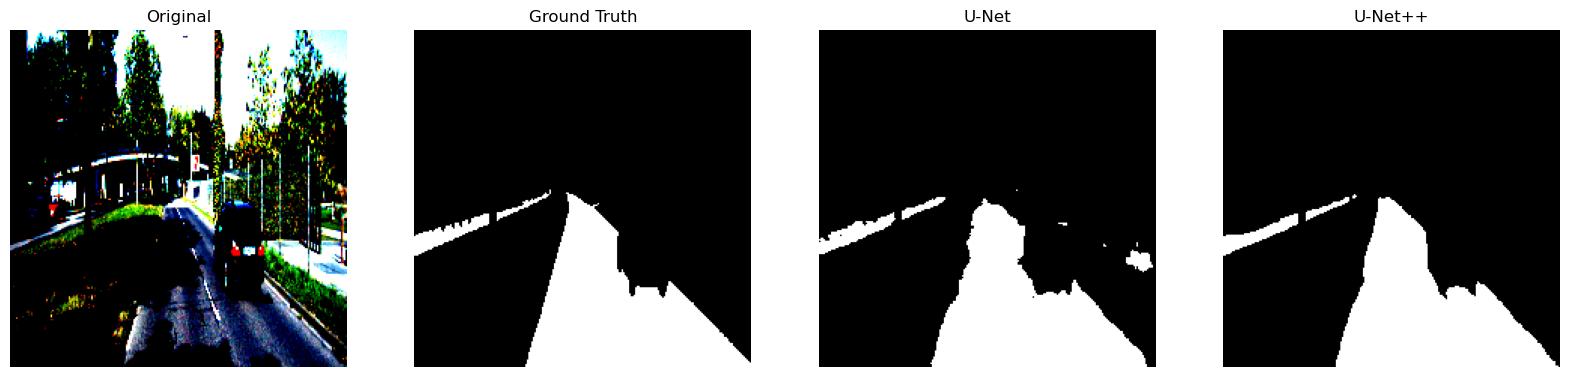

In [8]:
def visualize_results(model1, model2, loader):
    model1.eval(); model2.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    imgs, masks = next(iter(loader))
    imgs = imgs.to(device)

    # 기울기 연산은 제외해서 좀 빠르게 연산
    with torch.no_grad():
        # Sigmoid 이용해서 0.5보다 크면 도로로 판단.
        pred1 = torch.sigmoid(model1(imgs)) > 0.5
        pred2 = torch.sigmoid(model2(imgs)) > 0.5
        
    img, mask = imgs[0].cpu().permute(1,2,0).numpy(), masks[0].numpy()
    p1, p2 = pred1[0].cpu().squeeze().numpy(), pred2[0].cpu().squeeze().numpy()

    # 비교하기 쉽도록 4개 이미지 출력해서 비교
    titles = ['Original', 'Ground Truth', 'U-Net', 'U-Net++']
    images = [img, mask, p1, p2]
    
    plt.figure(figsize=(20, 5))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        plt.title(titles[i])
        plt.imshow(images[i], cmap='gray' if i>0 else None)
        plt.axis('off')
    plt.show()

visualize_results(unet, unet_pp, train_loader)

## 5. IoU 점수 비교

In [11]:
def calculate_iou(pred, target):
    # 이진화 처리 (0.5 기준)
    pred = (pred > 0.5).float()
    # 교집합. 예측과 정답이 둘 다 1인영역 합산
    intersection = (pred * target).sum()
    # 합집합. 예측영역 + 정답영역 - 교집합
    union = pred.sum() + target.sum() - intersection
    # 합집합이 0인경우, 1 반환(에러 방지용)
    if union == 0:
        return 1.0
    # 분모가 0이되는거 방지
    return (intersection / (union + 1e-6)).item()

def evaluate_models(unet_model, unet_pp_model, loader):
    unet_model.eval()
    unet_pp_model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    unet_iou_list = []
    unet_pp_iou_list = []
    
    print("--- 모델 성능 평가 ---")
    with torch.no_grad():
        for imgs, masks in loader:
            # 데이터 규격 맞춰주기
            imgs, masks = imgs.to(device), masks.unsqueeze(1).float().to(device)
            
            # U-Net 예측 및 IoU 계산
            out_u = torch.sigmoid(unet_model(imgs))
            unet_iou_list.append(calculate_iou(out_u, masks))
            
            # U-Net++ 예측 및 IoU 계산
            out_upp = torch.sigmoid(unet_pp_model(imgs))
            unet_pp_iou_list.append(calculate_iou(out_upp, masks))

    # 전체 이미지에 대한 IoU 평균값 산출
    avg_unet = np.mean(unet_iou_list)
    avg_unet_pp = np.mean(unet_pp_iou_list)
    
    print("\n" + "="*30)
    print(f"{'Model':<15} | {'Mean IoU':<10}")
    print("-" * 30)
    print(f"{'U-Net':<15} | {avg_unet:.4f}")
    print(f"{'U-Net++':<15} | {avg_unet_pp:.4f}")
    print("="*30)
    
    return avg_unet, avg_unet_pp

# 평가 실행
unet_score, unet_pp_score = evaluate_models(unet, unet_pp, train_loader)

--- 모델 성능 평가 시작 (전체 데이터셋) ---

Model           | Mean IoU  
------------------------------
U-Net           | 0.8414
U-Net++         | 0.9275


## 6. 최종 분석

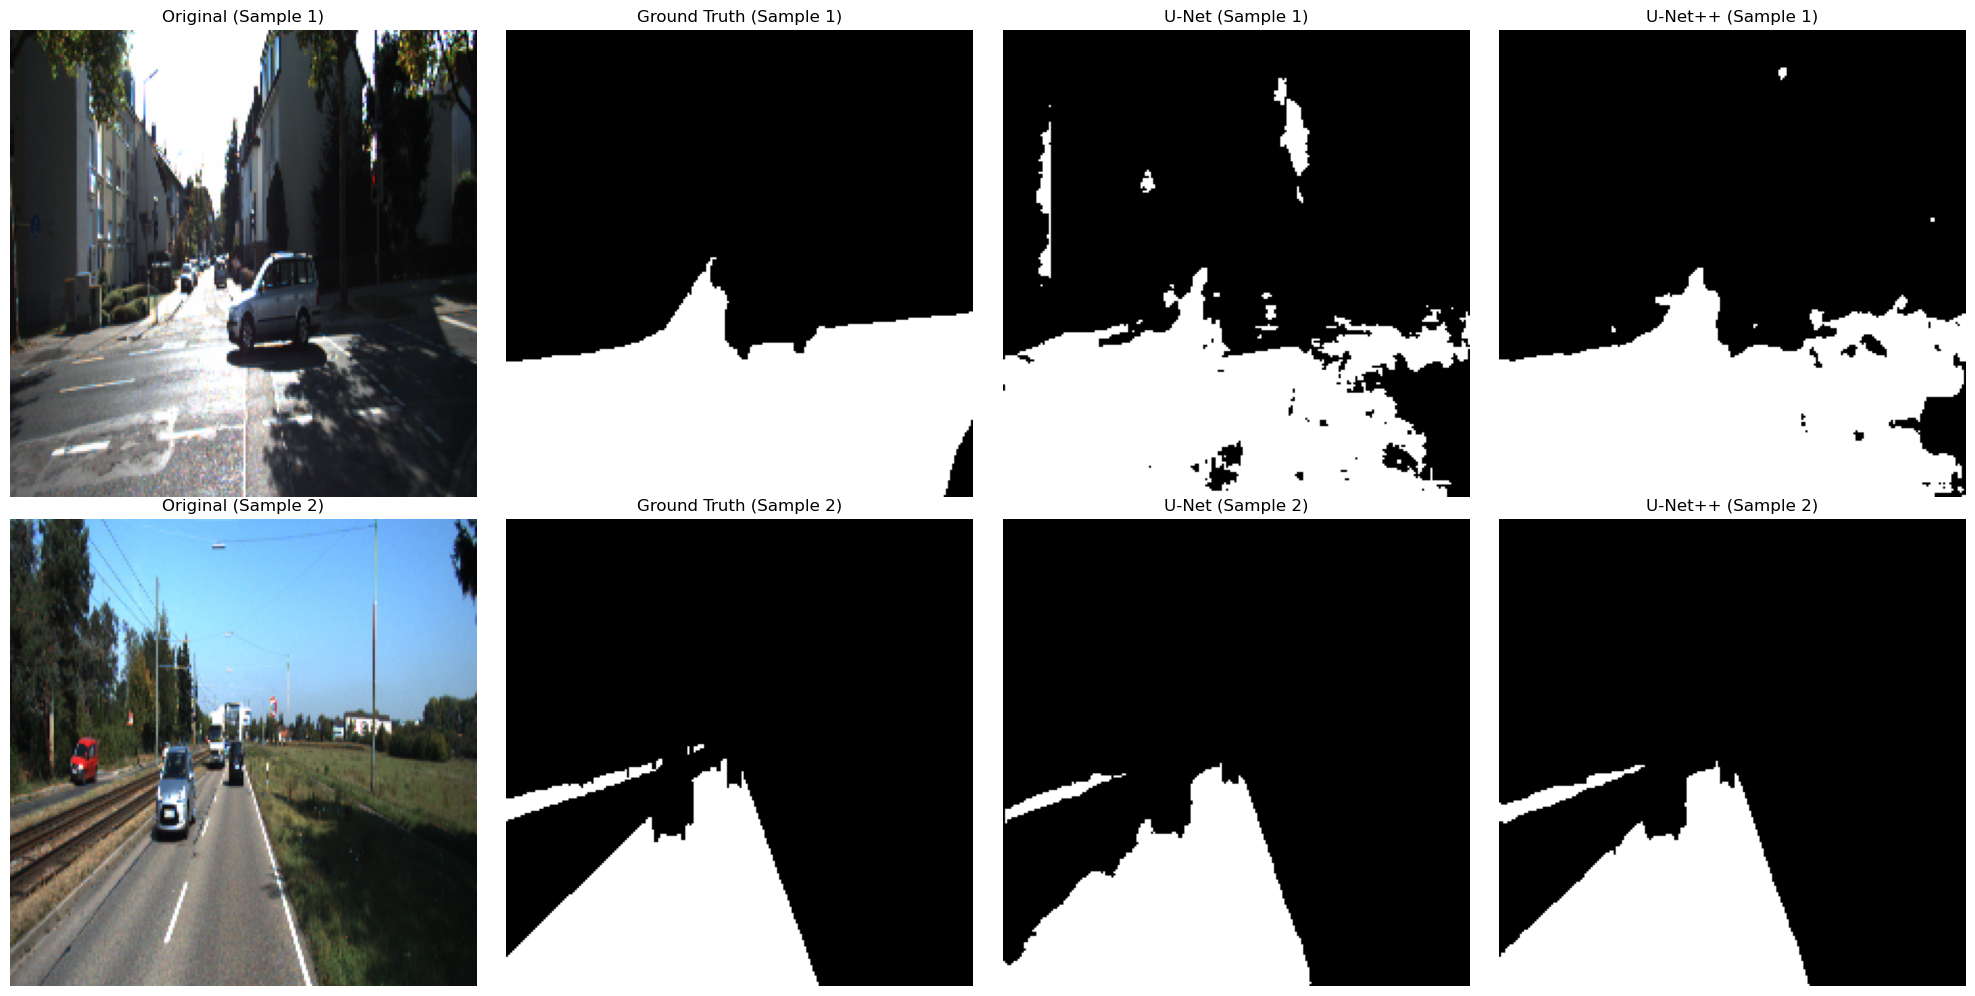

In [12]:
def plot_final_comparison(unet_model, unet_pp_model, loader):
    unet_model.eval()
    unet_pp_model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # 배치를 하나 가져와서 시각화
    imgs, masks = next(iter(loader))
    imgs = imgs.to(device)
    
    with torch.no_grad():
        pred_u = torch.sigmoid(unet_model(imgs)) > 0.5
        pred_upp = torch.sigmoid(unet_pp_model(imgs)) > 0.5
        
    plt.figure(figsize=(20, 10))
    
    # 4개 샘플에 대해 비교
    for i in range(2): # 2개 행
        img = imgs[i].cpu().permute(1, 2, 0).numpy()
        # 정규화 해제 (시각화용)
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        
        gt = masks[i].cpu().numpy()
        pu = pred_u[i].cpu().squeeze().numpy()
        pupp = pred_upp[i].cpu().squeeze().numpy()
        
        data = [img, gt, pu, pupp]
        titles = ['Original', 'Ground Truth', 'U-Net', 'U-Net++']
        
        for j in range(4):
            plt.subplot(2, 4, i*4 + j + 1)
            plt.imshow(data[j], cmap='gray' if j > 0 else None)
            plt.title(f"{titles[j]} (Sample {i+1})")
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()

plot_final_comparison(unet, unet_pp, train_loader)